# Tower Hamlets Charity Data

This notebook contains an exploration of the government's Charity Commission for England and Wales Tower Hamlets-specific charity dataset. The dataset was retrieved through their charity registry search tool and contains all charities that operate in the London borough of Tower Hamlets. Most of these charities are physically located/registered in the borough itself, while others are registered outside the borough but claim to operate within. In this notebook, I present an exploration of the dataset and delve into the creation of one new dataset for charities that are local to Tower Hamlets.

Retrieved from: https://register-of-charities.charitycommission.gov.uk/en/charity-search?p_p_id=uk_gov_ccew_portlet_CharitySearchPortlet&p_p_lifecycle=0&p_p_state=normal&p_p_mode=view&_uk_gov_ccew_portlet_CharitySearchPortlet_mvcRenderCommandName=/advanced-search

In [399]:
#importing necessary libraries for data manipulation and visualisation
import pandas as pd
import seaborn as sns
import numpy as np

#setting option for pandas to display all columns
pd.set_option('display.max_columns', None)

In [400]:
#reading csv file and creating dataframe
df = pd.read_csv('../data/raw_data/charitydetails_2026_02_06_19_43_11.csv')

### Exploratory Analysis

In [401]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Charity Number                648 non-null    int64  
 1   Charity Subsidiary Number     648 non-null    int64  
 2   Charity Name                  648 non-null    str    
 3   Charity Address               645 non-null    str    
 4   Charity Postcode              634 non-null    str    
 5   Charity Constituency          629 non-null    str    
 6   Phone                         643 non-null    str    
 7   Email                         589 non-null    str    
 8   Website                       451 non-null    str    
 9   Last Recorded Financial Year  629 non-null    str    
 10  Last Recorded Income          629 non-null    float64
 11  Last Recorded Expenditure     629 non-null    float64
 12  Charity Status                648 non-null    str    
 13  Charity Type    

In [402]:
df.head()

,Charity Number,Charity Subsidiary Number,Charity Name,Charity Address,Charity Postcode,Charity Constituency,Phone,Email,Website,Last Recorded Financial Year,Last Recorded Income,Last Recorded Expenditure,Charity Status,Charity Type,How the charity helps,What the charity does,Who the charity helps,Activities,Charity Objects
0,206225,0,TOWER HILL TRUST,"MARSHALL HOUSE, 66 NEWCOMEN STREET, LONDON",SE1 1YT,Bermondsey and Old Southwark,07926 927861,enquiries@towerhilltrust.org.uk,www.towerhilltrust.org.uk,30/04/2025,296895.0,188793.0,Registered,Other,"Makes Grants To Organisations, Provides Buildi...","General Charitable Purposes, The Advancement O...","Children/young People, Elderly/old People, Peo...",The Trust's objectives are to use its income f...,THE PROMOTION OF CHARITABLE PURPOSES FOR THE G...
1,206431,0,CHARITY OF MARY BAKER,"32 MONTHOPE ROAD, LONDON",E1 5LS,Bethnal Green and Stepney,02073771086,NaN,www.marybaker.org.uk,31/12/2024,8523.0,7908.0,Registered,Other,"Makes Grants To Individuals, Makes Grants To O...",The Prevention Or Relief Of Poverty,The General Public/mankind,The charity operates in the London Borough of ...,TO RELIEVE EITHER GENERALLY OR INDIVIDUALLY PE...
2,207243,0,NORTON FOLGATE ALMSHOUSE CHARITIES,"The Trust Partnership Ltd, 6 Trull Farm Buildi...",GL8 8SQ,South Cotswolds,01285 841900,nortonfolgate@thetrustpartnership.com,NaN,31/12/2024,240929.0,218271.0,Registered,Other,Provides Buildings/facilities/open Space,Accommodation/housing,Other Defined Groups,Provision of affordable almshouses for people ...,The Objects of the Charity are for the public ...
3,207454,0,PROVIDENCE ROW CHARITY,"PROVIDENCE ROW, DELLOW CENTRE, 82 WENTWORTH ST...",E1 7SA,Bethnal Green and Stepney,02074226382,info@providencerow.org.uk,www.providencerow.org.uk,31/03/2025,0.0,0.0,Registered,Other,Provides Other Finance,The Prevention Or Relief Of Poverty,Other Defined Groups,PROVIDENCE ROW CHARITY IS THE UNINCORPORATED P...,(1) THE OBJECT OF THE CHARITY IS THE RELIEF OF...
4,207664,0,THE MAITLAND TRUST,"178A, Ember Lane, East Molesey, Surrey",KT8 0BS,Esher and Walton,07535987310,NaN,NaN,31/12/2024,13529.0,13668.0,Registered,Other,Makes Grants To Organisations,"General Charitable Purposes, The Advancement O...","Children/young People, Elderly/old People, Peo...",The trust was registered in 1915. Its purpose ...,THE MAINTENANCE OF BEDS IN THE BERKS AND BUCKS...


Text(0.5, 1.0, 'Null Values')

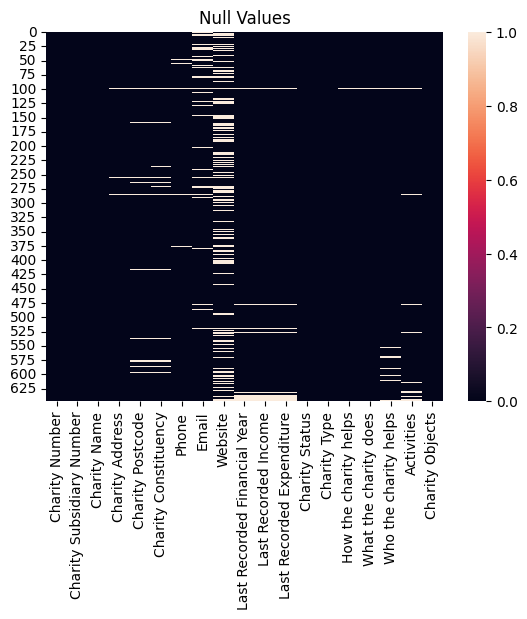

In [403]:
#simple heatmpa for all null values
sns.heatmap(df.isna()).set_title("Null Values")

There are 19 columns in the dataset.

### Cleaning Data

In [404]:
df.columns

Index(['Charity Number', 'Charity Subsidiary Number', 'Charity Name',
       'Charity Address', 'Charity Postcode', 'Charity Constituency', 'Phone',
       'Email', 'Website', 'Last Recorded Financial Year',
       'Last Recorded Income', 'Last Recorded Expenditure', 'Charity Status',
       'Charity Type', 'How the charity helps', 'What the charity does',
       'Who the charity helps', 'Activities', 'Charity Objects'],
      dtype='str')

In [405]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Charity Number                648 non-null    int64  
 1   Charity Subsidiary Number     648 non-null    int64  
 2   Charity Name                  648 non-null    str    
 3   Charity Address               645 non-null    str    
 4   Charity Postcode              634 non-null    str    
 5   Charity Constituency          629 non-null    str    
 6   Phone                         643 non-null    str    
 7   Email                         589 non-null    str    
 8   Website                       451 non-null    str    
 9   Last Recorded Financial Year  629 non-null    str    
 10  Last Recorded Income          629 non-null    float64
 11  Last Recorded Expenditure     629 non-null    float64
 12  Charity Status                648 non-null    str    
 13  Charity Type    

##### Charity Status and Subsidiary Number

In [406]:
df['Charity Status'].value_counts()

Charity Status
Registered    648
Name: count, dtype: int64

In [407]:
df['Charity Subsidiary Number'].unique()

array([0])

In [408]:
df = df.drop(columns=['Charity Subsidiary Number', 'Charity Status'])

##### Website, Email and Phone Columns

In [409]:
df['Website'].isna()

0      False
1      False
2       True
3      False
4       True
       ...  
643     True
644     True
645     True
646     True
647    False
Name: Website, Length: 648, dtype: bool

In [410]:
df['Website'] = df['Website'].fillna('Not available')
df['Email'] = df['Email'].fillna('Not available')
df['Phone'] = df['Phone'].fillna('Not available')

In [411]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Charity Number                648 non-null    int64  
 1   Charity Name                  648 non-null    str    
 2   Charity Address               645 non-null    str    
 3   Charity Postcode              634 non-null    str    
 4   Charity Constituency          629 non-null    str    
 5   Phone                         648 non-null    str    
 6   Email                         648 non-null    str    
 7   Website                       648 non-null    str    
 8   Last Recorded Financial Year  629 non-null    str    
 9   Last Recorded Income          629 non-null    float64
 10  Last Recorded Expenditure     629 non-null    float64
 11  Charity Type                  648 non-null    str    
 12  How the charity helps         647 non-null    str    
 13  What the charity

#### Standardizing Text Fields

In [412]:
df['Charity Name'] = df['Charity Name'].str.strip().str.upper()
df['Charity Address'] = df['Charity Address'].str.strip()
df['Charity Postcode'] = df['Charity Postcode'].str.strip().str.upper()

In [413]:
df.head()

,Charity Number,Charity Name,Charity Address,Charity Postcode,Charity Constituency,Phone,Email,Website,Last Recorded Financial Year,Last Recorded Income,Last Recorded Expenditure,Charity Type,How the charity helps,What the charity does,Who the charity helps,Activities,Charity Objects
0,206225,TOWER HILL TRUST,"MARSHALL HOUSE, 66 NEWCOMEN STREET, LONDON",SE1 1YT,Bermondsey and Old Southwark,07926 927861,enquiries@towerhilltrust.org.uk,www.towerhilltrust.org.uk,30/04/2025,296895.0,188793.0,Other,"Makes Grants To Organisations, Provides Buildi...","General Charitable Purposes, The Advancement O...","Children/young People, Elderly/old People, Peo...",The Trust's objectives are to use its income f...,THE PROMOTION OF CHARITABLE PURPOSES FOR THE G...
1,206431,CHARITY OF MARY BAKER,"32 MONTHOPE ROAD, LONDON",E1 5LS,Bethnal Green and Stepney,02073771086,Not available,www.marybaker.org.uk,31/12/2024,8523.0,7908.0,Other,"Makes Grants To Individuals, Makes Grants To O...",The Prevention Or Relief Of Poverty,The General Public/mankind,The charity operates in the London Borough of ...,TO RELIEVE EITHER GENERALLY OR INDIVIDUALLY PE...
2,207243,NORTON FOLGATE ALMSHOUSE CHARITIES,"The Trust Partnership Ltd, 6 Trull Farm Buildi...",GL8 8SQ,South Cotswolds,01285 841900,nortonfolgate@thetrustpartnership.com,Not available,31/12/2024,240929.0,218271.0,Other,Provides Buildings/facilities/open Space,Accommodation/housing,Other Defined Groups,Provision of affordable almshouses for people ...,The Objects of the Charity are for the public ...
3,207454,PROVIDENCE ROW CHARITY,"PROVIDENCE ROW, DELLOW CENTRE, 82 WENTWORTH ST...",E1 7SA,Bethnal Green and Stepney,02074226382,info@providencerow.org.uk,www.providencerow.org.uk,31/03/2025,0.0,0.0,Other,Provides Other Finance,The Prevention Or Relief Of Poverty,Other Defined Groups,PROVIDENCE ROW CHARITY IS THE UNINCORPORATED P...,(1) THE OBJECT OF THE CHARITY IS THE RELIEF OF...
4,207664,THE MAITLAND TRUST,"178A, Ember Lane, East Molesey, Surrey",KT8 0BS,Esher and Walton,07535987310,Not available,Not available,31/12/2024,13529.0,13668.0,Other,Makes Grants To Organisations,"General Charitable Purposes, The Advancement O...","Children/young People, Elderly/old People, Peo...",The trust was registered in 1915. Its purpose ...,THE MAINTENANCE OF BEDS IN THE BERKS AND BUCKS...


### Feature Engineering

#### Tower Hamlets Only

In [414]:
th_pattern = r'^(E1\b|E1W|E2\b|E3\b|E14\b)'
df['TH Postcode'] = df['Charity Postcode'].str.match(th_pattern, na=False)

In [415]:
df['TH Postcode'].value_counts()

TH Postcode
True     374
False    274
Name: count, dtype: int64

#### Charity Size

In [416]:
df['Last Recorded Income']

0      296895.0
1        8523.0
2      240929.0
3           0.0
4       13529.0
         ...   
643         NaN
644         NaN
645         NaN
646         NaN
647         NaN
Name: Last Recorded Income, Length: 648, dtype: float64

The UK Civil Society Almanac presents the following organization income brackets to break down the sector.
https://www.ncvo.org.uk/news-and-insights/news-index/uk-civil-society-almanac-2023/profile/how-many-voluntary-organisations-are-there/

In [417]:
income_bands = [0, 10000, 100000, 1000000, 10000000, float('inf')]
labels = ['Micro', 'Small', 'Medium', 'Large', 'Major']

In [418]:
df['Charity Size Band'] = pd.cut(df['Last Recorded Income'], bins=income_bands, labels=labels, right=True)

In [419]:
df['Size Band'] = df.loc[df['Last Recorded Income'].isna(), 'Size Band'] = 'No Filing'

In [420]:
df['Size Band'] = df.loc[df['Last Recorded Income'] == 0, 'Size Band'] = 'Dormant'

In [421]:
df.head()

,Charity Number,Charity Name,Charity Address,Charity Postcode,Charity Constituency,Phone,Email,Website,Last Recorded Financial Year,Last Recorded Income,Last Recorded Expenditure,Charity Type,How the charity helps,What the charity does,Who the charity helps,Activities,Charity Objects,TH Postcode,Charity Size Band,Size Band
0,206225,TOWER HILL TRUST,"MARSHALL HOUSE, 66 NEWCOMEN STREET, LONDON",SE1 1YT,Bermondsey and Old Southwark,07926 927861,enquiries@towerhilltrust.org.uk,www.towerhilltrust.org.uk,30/04/2025,296895.0,188793.0,Other,"Makes Grants To Organisations, Provides Buildi...","General Charitable Purposes, The Advancement O...","Children/young People, Elderly/old People, Peo...",The Trust's objectives are to use its income f...,THE PROMOTION OF CHARITABLE PURPOSES FOR THE G...,False,Medium,Dormant
1,206431,CHARITY OF MARY BAKER,"32 MONTHOPE ROAD, LONDON",E1 5LS,Bethnal Green and Stepney,02073771086,Not available,www.marybaker.org.uk,31/12/2024,8523.0,7908.0,Other,"Makes Grants To Individuals, Makes Grants To O...",The Prevention Or Relief Of Poverty,The General Public/mankind,The charity operates in the London Borough of ...,TO RELIEVE EITHER GENERALLY OR INDIVIDUALLY PE...,True,Micro,Dormant
2,207243,NORTON FOLGATE ALMSHOUSE CHARITIES,"The Trust Partnership Ltd, 6 Trull Farm Buildi...",GL8 8SQ,South Cotswolds,01285 841900,nortonfolgate@thetrustpartnership.com,Not available,31/12/2024,240929.0,218271.0,Other,Provides Buildings/facilities/open Space,Accommodation/housing,Other Defined Groups,Provision of affordable almshouses for people ...,The Objects of the Charity are for the public ...,False,Medium,Dormant
3,207454,PROVIDENCE ROW CHARITY,"PROVIDENCE ROW, DELLOW CENTRE, 82 WENTWORTH ST...",E1 7SA,Bethnal Green and Stepney,02074226382,info@providencerow.org.uk,www.providencerow.org.uk,31/03/2025,0.0,0.0,Other,Provides Other Finance,The Prevention Or Relief Of Poverty,Other Defined Groups,PROVIDENCE ROW CHARITY IS THE UNINCORPORATED P...,(1) THE OBJECT OF THE CHARITY IS THE RELIEF OF...,True,NaN,Dormant
4,207664,THE MAITLAND TRUST,"178A, Ember Lane, East Molesey, Surrey",KT8 0BS,Esher and Walton,07535987310,Not available,Not available,31/12/2024,13529.0,13668.0,Other,Makes Grants To Organisations,"General Charitable Purposes, The Advancement O...","Children/young People, Elderly/old People, Peo...",The trust was registered in 1915. Its purpose ...,THE MAINTENANCE OF BEDS IN THE BERKS AND BUCKS...,False,Small,Dormant


#### Charity Activity

In [422]:
#
categories = df['What the charity does'].str.split(r',\s*').explode().str.strip()
frequency = categories.value_counts().to_dict()

In [423]:
def most_specific(tags):
    if pd.isna(tags):
        return 'Unknown'
    split = [t.strip() for t in tags.split(',')]
    return min(split, key=lambda t: frequency.get(t, 999))

In [424]:
df['Primary Focus'] = df['What the charity does'].apply(most_specific)

In [425]:
df.head()

,Charity Number,Charity Name,Charity Address,Charity Postcode,Charity Constituency,Phone,Email,Website,Last Recorded Financial Year,Last Recorded Income,Last Recorded Expenditure,Charity Type,How the charity helps,What the charity does,Who the charity helps,Activities,Charity Objects,TH Postcode,Charity Size Band,Size Band,Primary Focus
0,206225,TOWER HILL TRUST,"MARSHALL HOUSE, 66 NEWCOMEN STREET, LONDON",SE1 1YT,Bermondsey and Old Southwark,07926 927861,enquiries@towerhilltrust.org.uk,www.towerhilltrust.org.uk,30/04/2025,296895.0,188793.0,Other,"Makes Grants To Organisations, Provides Buildi...","General Charitable Purposes, The Advancement O...","Children/young People, Elderly/old People, Peo...",The Trust's objectives are to use its income f...,THE PROMOTION OF CHARITABLE PURPOSES FOR THE G...,False,Medium,Dormant,Accommodation/housing
1,206431,CHARITY OF MARY BAKER,"32 MONTHOPE ROAD, LONDON",E1 5LS,Bethnal Green and Stepney,02073771086,Not available,www.marybaker.org.uk,31/12/2024,8523.0,7908.0,Other,"Makes Grants To Individuals, Makes Grants To O...",The Prevention Or Relief Of Poverty,The General Public/mankind,The charity operates in the London Borough of ...,TO RELIEVE EITHER GENERALLY OR INDIVIDUALLY PE...,True,Micro,Dormant,The Prevention Or Relief Of Poverty
2,207243,NORTON FOLGATE ALMSHOUSE CHARITIES,"The Trust Partnership Ltd, 6 Trull Farm Buildi...",GL8 8SQ,South Cotswolds,01285 841900,nortonfolgate@thetrustpartnership.com,Not available,31/12/2024,240929.0,218271.0,Other,Provides Buildings/facilities/open Space,Accommodation/housing,Other Defined Groups,Provision of affordable almshouses for people ...,The Objects of the Charity are for the public ...,False,Medium,Dormant,Accommodation/housing
3,207454,PROVIDENCE ROW CHARITY,"PROVIDENCE ROW, DELLOW CENTRE, 82 WENTWORTH ST...",E1 7SA,Bethnal Green and Stepney,02074226382,info@providencerow.org.uk,www.providencerow.org.uk,31/03/2025,0.0,0.0,Other,Provides Other Finance,The Prevention Or Relief Of Poverty,Other Defined Groups,PROVIDENCE ROW CHARITY IS THE UNINCORPORATED P...,(1) THE OBJECT OF THE CHARITY IS THE RELIEF OF...,True,NaN,Dormant,The Prevention Or Relief Of Poverty
4,207664,THE MAITLAND TRUST,"178A, Ember Lane, East Molesey, Surrey",KT8 0BS,Esher and Walton,07535987310,Not available,Not available,31/12/2024,13529.0,13668.0,Other,Makes Grants To Organisations,"General Charitable Purposes, The Advancement O...","Children/young People, Elderly/old People, Peo...",The trust was registered in 1915. Its purpose ...,THE MAINTENANCE OF BEDS IN THE BERKS AND BUCKS...,False,Small,Dormant,Accommodation/housing


### Exporting Clean Data

##### All Charities Operating in Tower Hamlets

In [426]:
all_charities_working_th = df.to_csv('../data/clean_data/all_charities.csv')

##### Micro, Small and Medium Sized Charities in Tower Hamlets

These are charities that are located within the borough that might need help from the council or seek local volunteers.

In [427]:
th_micro_small_med_charities = df[(df['TH Postcode'] == True) & (df['Charity Size Band'].isin(['Micro', 'Small', 'Medium']))]

In [428]:
th_micro_small_med_charities.to_csv('../data/clean_data/micro_small_med_charities_TH.csv')

In [431]:
th_micro_small_med_charities.head(25)

,Charity Number,Charity Name,Charity Address,Charity Postcode,Charity Constituency,Phone,Email,Website,Last Recorded Financial Year,Last Recorded Income,Last Recorded Expenditure,Charity Type,How the charity helps,What the charity does,Who the charity helps,Activities,Charity Objects,TH Postcode,Charity Size Band,Size Band,Primary Focus
1,206431,CHARITY OF MARY BAKER,"32 MONTHOPE ROAD, LONDON",E1 5LS,Bethnal Green and Stepney,02073771086,Not available,www.marybaker.org.uk,31/12/2024,8523.0,7908.0,Other,"Makes Grants To Individuals, Makes Grants To O...",The Prevention Or Relief Of Poverty,The General Public/mankind,The charity operates in the London Borough of ...,TO RELIEVE EITHER GENERALLY OR INDIVIDUALLY PE...,True,Micro,Dormant,The Prevention Or Relief Of Poverty
5,207772,HENRY FAWCETT FUND,"ST PETER'S CHURCH OFFICE, The Vicarage, St. Pe...",E2 7AE,Bethnal Green and Stepney,02070330244,info@stpetersbethnalgreen.org,Not available,31/12/2024,103540.0,22604.0,Other,"Makes Grants To Individuals, Makes Grants To O...","General Charitable Purposes, Education/trainin...","Children/young People, Elderly/old People, Peo...",The charity is restricted to the benefit of pe...,"GENERAL BENEFIT OF POOR PERSONS, IF POSSIBLE T...",True,Medium,Dormant,Accommodation/housing
6,208870,SALMON LANE MISSION,"168-170 SALMON LANE, LIMEHOUSE, LONDON",E14 7PQ,Poplar and Limehouse,02079879960,Not available,Not available,30/09/2024,15920.0,10862.0,Charitable company,"Provides Buildings/facilities/open Space, Prov...","Education/training, The Prevention Or Relief O...",The General Public/mankind,"The work consists of promoting, organising, co...","TO PROMOTE, ORGANISE, CONDUCT AND CARRY ON CHA...",True,Small,Dormant,Overseas Aid/famine Relief
7,209117,THE STRANGERS REST MISSION,"Strangers Rest Church, 131 The Highway, LONDON",E1W 2BP,Bethnal Green and Stepney,0795 6188 505,mlrmullins@gmail.com,http://www.strangersrest.org/,30/09/2024,40208.0,48706.0,Other,"Provides Human Resources, Provides Buildings/f...","Disability, The Prevention Or Relief Of Povert...","Children/young People, Elderly/old People, Peo...",THE STRANGERS' REST MISSION IS A CHRISTIAN ORG...,EVANGELISTIC CHRISTIAN MISSION PURPOSES IN THE...,True,Small,Dormant,Disability
9,210928,EAST LONDON NURSING SOCIETY TRUST,"45-55 Whitehorse Road, LONDON",E1 0ND,Bethnal Green and Stepney,02077909085,info@towerproject.org.uk,Not available,31/03/2024,17556.0,4896.0,Other,Makes Grants To Organisations,"The Advancement Of Health Or Saving Of Lives, ...","Children/young People, Elderly/old People, Peo...",Making grants to groups providing support for ...,TO RELIEVE IN CASES OF NEED PERSONS RESIDENT I...,True,Small,Dormant,Disability
10,211196,POPLAR METHODIST CHURCH SICK & POOR FUND,"Bow Road Methodist Church, 1 Merchant Street, ...",E3 4LY,Stratford and Bow,02088807301,admin@mcth.org.uk,Not available,31/08/2024,855.0,60.0,Other,Makes Grants To Individuals,The Prevention Or Relief Of Poverty,"Elderly/old People, Other Defined Groups",Support to needy people in the historical boro...,GRANTS FOR POOR PERSONS RESIDING IN POPLAR WHO...,True,Micro,Dormant,The Prevention Or Relief Of Poverty
11,211399,PARISH OF POPLAR BENEVOLENT FUND,"St. Michael's Vicarage, 164 St. Leonards Road,...",E14 6PW,Poplar and Limehouse,02079878625,allsaints.poplar@tiscali.co.uk,http://www.parishofpoplar.com/,31/12/2024,4590.0,1094.0,Other,"Makes Grants To Individuals, Makes Grants To O...","General Charitable Purposes, The Prevention Or...",Other Defined Groups,Small grants of money or the purchase of neede...,FOR THE BENEFIT OF THE DESEVING POOR.,True,Micro,Dormant,The Prevention Or Relief Of Poverty
12,211536,SELDEN SOCIETY,"QUEEN MARY UNIVERSITY OF LONDON, 327 MILE END ...",E1 4NS,Bethnal Green and Stepney,02078823968,selden-society@qmul.ac.uk,www.seldensociety.ac.uk,31/12/2024,116834.0,76761.0,Other,"Provides Advocacy/advice/information, Sponsors...",Education/training,Other Defined Groups,To encourage the study and advance the

In [433]:
list(th_micro_small_med_charities['Charity Number'].head(10))

[206431,
 207772,
 208870,
 209117,
 210928,
 211196,
 211399,
 211536,
 222262,
 228069]